# Dynamic Multi-Objective Ant Colony Optimization (MOACO) with Ranking

This notebook implements a **Dynamic Multi-Objective Ant Colony Optimization (MOACO)** algorithm for path planning on a 2-D grid that contains both static and dynamic (moving) obstacles. The algorithm discovers a set of Pareto-optimal paths that simultaneously minimise four competing objectives:

| # | Objective | Description | Goal |
|---|-----------|-------------|------|
| 1 | **Path Length** | Total 3-D Euclidean distance (includes elevation) | Minimise |
| 2 | **Smoothness** | Weighted sum of turning angles + sharp-turn count | Minimise |
| 3 | **Elevation Change** | Total absolute altitude change along the route | Minimise |
| 4 | **Safety Penalty** | Proximity-weighted exposure to static & dynamic obstacles | Minimise |

### High-Level Algorithm
1. Each iteration, a colony of ants independently constructs a path from `(0,0)` to `(N-1, N-1)`.
2. At every step, an ant scores candidate neighbours with four heuristics and samples the next cell proportionally to `heuristic^α × pheromone^β`.
3. All candidate paths (current ants + Pareto archive) are ranked by **NSGA-II non-dominated sorting**.
4. The top solutions form a new Pareto archive. Solutions are ranked by front, penalised by age (to encourage exploration), and by niche count (to preserve diversity).
5. Pheromones evaporate uniformly and are reinforced by archived solutions weighted by rank / (age × niche_count).


## Imports and Configuration

Standard scientific-Python libraries are imported alongside `tqdm` for progress bars.  
`GRID_SIZE` sets the square grid dimension; `TYPE` is used as a filename tag so that artefacts for different grid sizes never collide.


In [18]:
import pickle
import numpy as np
import random
from IPython.display import clear_output
import time
from matplotlib import pyplot as plt
from matplotlib import patches as patches
from matplotlib import colors
from tqdm.notebook import tqdm
import copy
import math
from enum import Enum

class PheromoneUpdateType(Enum):
    RANK_AND_NC = 1
    AGE_AND_NC = 2
    RANK_AND_AGE = 3
    ALL = 4

# Grid dimension — produces a GRID_SIZE × GRID_SIZE environment.
# REVIEWER 1: Point 4
GRID_SIZE = 15
TYPE = f"{GRID_SIZE}x{GRID_SIZE}"  # Used as a suffix in all file paths


## 2. Core Data Structures

Three classes model the environment and the agents:

| Class | Role |
|-------|------|
| **`Obstacle`** | A contiguous cluster of blocked cells; can be static (green) or dynamic (red, bouncing velocity). |
| **`GridEnv`** | The simulation grid; owns obstacle list, elevation map, and pheromone matrix. |
| **`Ant`** | A single agent that walks from `(0,0)` to the goal, recording each step. |

The standalone helper **`extract_clusters_and_create_obstacles`** labels connected components (8-connectivity) in a binary obstacle map and wraps each cluster in an `Obstacle` object.


In [19]:
class Obstacle:
    """A contiguous cluster of blocked grid cells that can be static or dynamic.

    Classification and initial velocity are derived deterministically from the
    cluster's minimum row/column position, so the same obstacle map always
    recreates the same scene.

    Attributes
    ----------
    curr_pos : list of [int, int]
        Current cell positions forming this obstacle cluster.
    start : list of [int, int]
        Original positions used when resetting.
    rows, cols : int
        Parent-grid dimensions (used for boundary checks).
    color : tuple
        RGB render colour: green (0,1,0) for static, red (1,0,0) for dynamic.
    static : bool
        True when the obstacle does not move.
    velocity : [int, int]
        Current [row_delta, col_delta] per time-step.
    start_velocity : [int, int]
        Original velocity — restored on reset().
    """

    def __init__(self, curr_pos, rows, cols):
        """Initialise an obstacle from a list of cell positions.

        Parameters
        ----------
        curr_pos : list of list[int]
            Cell coordinates [row, col] belonging to this cluster.
        rows, cols : int
            Total grid dimensions.
        """
        self.curr_pos = [list(p) for p in curr_pos]
        self.start    = [list(p) for p in curr_pos]
        self.rows     = rows
        self.cols     = cols
        self.color    = (0, 0, 0)
        self.static   = False

        if self.curr_pos:
            min_r = min(p[0] for p in self.curr_pos)
            min_c = min(p[1] for p in self.curr_pos)

            # Even manhattan parity → static; odd → dynamic
            self.static = (min_c + min_r) % 2 == 0

            # Deterministic velocity: maps position modulo 3 to {-1, 0, 1}
            vx = (min_r % 3) - 1
            vy = (min_c % 3) - 1

            if self.static:
                vx, vy = 0, 0
                self.color = (0, 1, 0)  # Green — static obstacle
            else:
                self.color = (1, 0, 0)  # Red — dynamic obstacle
                # Prevent zero-velocity dynamic obstacles
                if vx == 0 and vy == 0:
                    vx, vy = 1, 1
        else:
            vx, vy = 0, 0

        self.velocity       = [vx, vy]
        self.start_velocity = [vx, vy]

    def move(self):
        """Advance the obstacle one time-step, bouncing off grid boundaries.

        The velocity component along an axis is reversed whenever any cluster
        cell would leave the grid, implementing a simple bounce-off-the-wall
        motion model. Static obstacles are skipped entirely.
        """
        if self.static:
            return

        bounce_x = any(
            (p[0] <= 0 and self.velocity[0] < 0) or
            (p[0] >= self.rows - 1 and self.velocity[0] > 0)
            for p in self.curr_pos
        )
        bounce_y = any(
            (p[1] <= 0 and self.velocity[1] < 0) or
            (p[1] >= self.cols - 1 and self.velocity[1] > 0)
            for p in self.curr_pos
        )

        if bounce_x:
            self.velocity[0] *= -1
        if bounce_y:
            self.velocity[1] *= -1

        self.curr_pos = [
            [p[0] + self.velocity[0], p[1] + self.velocity[1]]
            for p in self.curr_pos
        ]

    def reset(self):
        """Restore the obstacle to its original position and velocity."""
        self.curr_pos = [list(p) for p in self.start]
        self.velocity = list(self.start_velocity)


def extract_clusters_and_create_obstacles(grid, rows, cols):
    """Detect connected obstacle clusters and wrap each in an Obstacle object.

    Uses an iterative depth-first search with **8-connectivity** to identify
    all contiguous groups of blocked cells (value == 1) in `grid`.

    Parameters
    ----------
    grid : 2-D array-like
        Binary map: 1 = obstacle cell, 0 = free cell.
    rows, cols : int
        Grid dimensions.

    Returns
    -------
    list of Obstacle
        One Obstacle instance per connected component found.
    """
    visited   = set()
    obstacles = []

    for r in range(rows):
        for c in range(cols):
            if grid[r][c] == 1 and (r, c) not in visited:
                cluster = []
                stack   = [(r, c)]
                while stack:
                    cr, cc = stack.pop()
                    if (cr, cc) not in visited:
                        visited.add((cr, cc))
                        cluster.append([cr, cc])
                        # Explore all 8 neighbours
                        for dr, dc in [(-1,0),(1,0),(0,-1),(0,1),
                                       (-1,-1),(-1,1),(1,-1),(1,1)]:
                            nr, nc = cr + dr, cc + dc
                            if 0 <= nr < rows and 0 <= nc < cols:
                                if grid[nr][nc] == 1 and (nr, nc) not in visited:
                                    stack.append((nr, nc))
                obstacles.append(Obstacle(curr_pos=cluster, rows=rows, cols=cols))

    return obstacles


class GridEnv:
    """2-D grid environment for dynamic-obstacle path planning.

    Maintains the occupancy map, elevation data, pheromone matrix, and
    obstacle list. Provides methods to step obstacles forward, query
    feasible moves, and render the current scene.

    Attributes
    ----------
    dx, dy : list of int
        Row and column deltas for the eight movement directions
        (N, E, S, W, NE, SE, NW, SW).
    grid : np.ndarray, shape (rows, cols)
        Occupancy map: 0 = free, non-zero = blocked.
    rows, cols : int
        Grid dimensions.
    obstacles : list of Obstacle
    elevation_data : 2-D array-like
        Per-cell elevation; used in 3-D distance and smoothness calculations.
    safety_radius : int
        Half-width of the bounding square scanned when computing safety penalties.
    pheromone_list : np.ndarray, shape (rows, cols)
        Pheromone concentration per cell; updated each iteration.
    c_x, c_y : list of float
        Pixel-centre coordinates of cells (populated by _generate_figure).
    """

    def __init__(self, obstacles, grid=[], elevation_data=[], safety_radius=1):
        """Initialise the grid environment.

        Parameters
        ----------
        obstacles : list of Obstacle
        grid : array-like, optional
            Binary occupancy grid.
        elevation_data : array-like, optional
            Per-cell elevation values.
        safety_radius : int, optional
            Neighbourhood radius for safety-penalty scans (default: 1).
        """
        # 8-directional movement offsets: [N, E, S, W, NE, SE, NW, SW]
        self.dx = [-1, 0,  1, 0,  1,  1, -1, -1]
        self.dy = [ 0, 1,  0,-1,  1, -1,  1, -1]

        self.grid           = np.array(grid)
        self.rows           = len(self.grid)
        self.cols           = len(self.grid[0, :])
        self.obstacles      = obstacles
        self.elevation_data = elevation_data
        self.safety_radius  = safety_radius
        self.c_x            = []
        self.c_y            = []
        self.pheromone_list = np.zeros((self.rows, self.cols))

    def move_obstacles(self):
        """Advance all dynamic obstacles by one time-step.

        Clears each obstacle from the grid, calls Obstacle.move(), then
        re-marks its new position.
        """
        for obstacle in self.obstacles:
            self._change_value(-1, obstacle.curr_pos)
            obstacle.move()
            self._change_value( 1, obstacle.curr_pos)

    def _change_value(self, value, cluster_pos):
        """Add `value` to every grid cell in a cluster.

        Used internally to mark (+1) or clear (-1) obstacle cells when
        obstacles are moved or reset.

        Parameters
        ----------
        value : int
            Typically +1 to mark or -1 to clear.
        cluster_pos : list of [int, int]
            Cells belonging to the cluster.
        """
        for pos in cluster_pos:
            r, c = pos[0], pos[1]
            if 0 <= r < self.rows and 0 <= c < self.cols:
                self.grid[r, c] += value

    def _generate_figure(self):
        """Draw coloured rectangles for every grid cell in the current figure.

        Free cells are semi-transparent black (opacity ∝ elevation/10).
        Blocked cells use their owning obstacle's colour.
        Populates `self.c_x` and `self.c_y` with pixel-centre coordinates
        (row-major order).
        """
        self.c_x, self.c_y = [], []
        cell_size = 10.0
        x0, y0   = 5.0, 5.0
        x, y     = x0, y0

        for i in range(self.rows):
            for j in range(self.cols):
                if self.grid[i, j] == 0:
                    alpha = self.elevation_data[i][j] / 10
                    plt.gca().add_patch(
                        patches.Rectangle((x, y), cell_size, cell_size,
                                          facecolor=colors.to_rgba("black", alpha))
                    )
                else:
                    # Identify which obstacle owns this cell
                    grid_color = None
                    for obstacle in self.obstacles:
                        if [i, j] in obstacle.curr_pos:
                            grid_color = obstacle.color
                    assert grid_color is not None, f"Blocked cell ({i},{j}) has no owner."
                    plt.gca().add_patch(
                        patches.Rectangle((x, y), cell_size, cell_size,
                                          facecolor=grid_color)
                    )
                self.c_x.append(x + cell_size / 2)
                self.c_y.append(y + cell_size / 2)
                x += cell_size
            y -= cell_size
            x  = x0

    def plot(self, best):
        """Render the grid and overlay a path.

        Parameters
        ----------
        best : list of int
            Flat (row-major) cell indices forming the path to draw.
        """
        self._generate_figure()
        path_x = [self.c_x[k] for k in best]
        path_y = [self.c_y[k] for k in best]
        for k in best:
            plt.scatter(self.c_x[k], self.c_y[k], c="black")
        plt.gca().set_aspect("equal")
        plt.plot(path_x, path_y, "k")
        plt.show()
        time.sleep(0.1)
        plt.close()

    def reset_obstacles(self):
        """Return all obstacles to their original positions and velocities."""
        for obstacle in self.obstacles:
            self._change_value(-1, obstacle.curr_pos)
            obstacle.reset()
            self._change_value( 1, obstacle.curr_pos)

    def give_possible_steps(self, currX, currY, matrix):
        """Return feasible (unblocked, unvisited) neighbours of a cell.

        Parameters
        ----------
        currX, currY : int
            Current row and column indices.
        matrix : np.ndarray, shape (rows, cols)
            Binary visited map for the current ant (1 = already visited).

        Returns
        -------
        list of (int, int)
            Valid (row, col) next-step candidates.
        """
        feasible = []
        for dx, dy in zip(self.dx, self.dy):
            nx, ny = currX + dx, currY + dy
            if nx < 0 or ny < 0 or nx >= self.rows or ny >= self.cols:
                continue  # Out of bounds
            if self.grid[nx, ny] != 0:
                continue  # Blocked by an obstacle
            if matrix[nx, ny] == 1:
                continue  # Already visited this iteration
            feasible.append((nx, ny))
        return feasible


class Ant:
    """A single ant agent that constructs one path per iteration.

    The ant walks from (0, 0) toward the goal at (rows-1, cols-1),
    appending each chosen cell to its visited list.

    Attributes
    ----------
    row, col : int
        Grid dimensions (stored for reset).
    ant_x, ant_y : int
        Current position.
    visited : list of (int, int)
        Ordered path built so far this iteration.
    visited_matrix : np.ndarray, shape (row, col)
        Binary mask: 1 at each cell already visited.
    ant_path_length : float
        Accumulated path length placeholder (not actively updated here).
    safety_penalty : float
        Accumulated safety penalty placeholder (not actively updated here).
    """

    def __init__(self, row, col):
        """Initialise an ant for a grid of size row × col.

        Parameters
        ----------
        row, col : int
            Grid dimensions.
        """
        self.row = row
        self.col = col
        self.reset()

    def reset(self):
        """Reset the ant to the start cell (0, 0) for a new episode."""
        self.ant_x          = 0
        self.ant_y          = 0
        self.safety_penalty = 0
        self.ant_path_length = 0
        self.visited        = [(0, 0)]
        self.visited_matrix = np.zeros((self.row, self.col))
        self.visited_matrix[0, 0] = 1

    def reached_goal(self, goal):
        """Check whether the ant has reached the goal cell.

        Parameters
        ----------
        goal : (int, int)
            Target (row, col) cell.

        Returns
        -------
        bool
            True if the ant is currently at goal.
        """
        return self.ant_x == goal[0] and self.ant_y == goal[1]


## 3. Environment Setup

Pre-computed elevation and obstacle maps are loaded from disk, obstacle clusters are detected and wrapped in `Obstacle` objects, and a `GridEnv` instance is created that will be reused throughout the experiment.


In [20]:
# Load pre-computed per-cell elevation values
with open(f"{TYPE}/elevation_data{TYPE}.pickle", "rb") as file:
    elevation_data = pickle.load(file)

# Load binary obstacle occupancy map (1 = blocked, 0 = free)
with open(f"{TYPE}/obstacle_map{TYPE}.pickle", "rb") as file:
    obstacle_map = pickle.load(file)


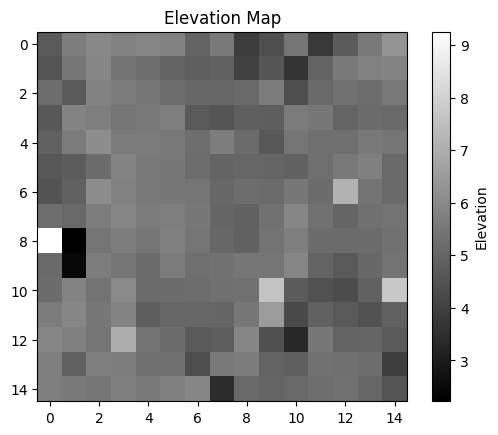

Max elevation: 9.254901960784315, Min elevation: 2.2222222222222223


In [21]:
# Visualise the elevation data and report its range
plt.imshow(elevation_data, cmap="gray")
plt.title("Elevation Map")
plt.colorbar(label="Elevation")
plt.show()

max_elevation = np.max(elevation_data)
min_elevation = np.min(elevation_data)
print(f"Max elevation: {max_elevation}, Min elevation: {min_elevation}")


In [22]:
# Detect connected obstacle clusters in the binary map and create Obstacle objects
obstacle_objects = extract_clusters_and_create_obstacles(
    obstacle_map, GRID_SIZE, GRID_SIZE
)
print(f"Total obstacle clusters found: {len(obstacle_objects)}")


Total obstacle clusters found: 9


In [23]:
# Instantiate the simulation environment.
# Deep copies are used so the originals remain available for later re-initialisation.
env = GridEnv(
    obstacles=copy.deepcopy(obstacle_objects),
    grid=copy.deepcopy(obstacle_map),
    elevation_data=copy.deepcopy(elevation_data),
    safety_radius=2
)


## Algorithm Hyperparameters

All tuneable constants are collected here for easy experimentation.

In [24]:
# ── Iteration control ──────────────────────────────
num_iterations = 100

# ── ACO probability-rule weights ───────────────────
alpha = 0.80   # Heuristic exponent
beta  = 0.35   # Pheromone exponent
gamma = 0.25   # Evaporation coefficient (fraction lost per iteration)

# ── Colony ─────────────────────────────────────────
num_ants                  = 6 # (M) Number of ants per iteration
random_choice_probability = 0 # (Not defined in paper. Used for implementation) Set > 0 to add random exploration

# ── Smoothness metric ──────────────────────────────
turning_angle_coeff = 0.8   # (W_1) Weight for cumulative angle sum
angle_threshold     = 1.8   # (Not defined in paper. Used for implementation) Degrees: threshold for a "sharp turn"
num_turns_coeff     = 0.2   # (W_2) Weight for the sharp-turn count

# ── Pareto archive ─────────────────────────────────
# REVIEWER 1: Point 1
max_age_item      = 100  # Cap on how old an archived solution can get
pareto_front_size = 12   # Maximum number of solutions kept in the archive

# ── Safety metric ──────────────────────────────────
static_obs  = 0.2    # (gamma_1) Fixed penalty for proximity to a static obstacle
dynamic_obs = 0.8    # (gamma_2) Base multiplier for proximity to a dynamic obstacle

# ── Safety threshold ───────────────────────────────
min_safe_distance = 1.25  # (R_s) Grid units: minimum safe distance to any obstacle

# ── Safety mode ───────────────────────────────────
use_dynamic_safety = False  # True  → get_safety_of_path_dynamic (obstacles move with the ant)
                           # False → get_safety_of_path         (static snapshot; no env needed)

pheromone_update_mode = PheromoneUpdateType.ALL


## Objective and Utility Functions

These functions evaluate the four objectives for any candidate path, compute navigation heuristics used during ant path construction, and implement the roulette-wheel selection procedure.

### Path Objectives
| Function | Objective |
|----------|-----------|
| `get_distance_of_path` | Total 3-D Euclidean length (elevation-adjusted) |
| `get_smoothness_of_path` | Weighted turning-angle sum + sharp-turn count |
| `get_elevation_of_path` | Total absolute elevation change |
| `get_safety_of_path_dynamic` | Cumulative proximity penalty (obstacles stepped forward with path) |
| `get_safety_of_path` | Static proximity penalty using a fixed snapshot of obstacle positions (no `env` argument) |

### Navigation Heuristics
| Function | Purpose |
|----------|---------|
| `get_distance` | 3-D Euclidean distance between two cells |
| `magnitude` | L2 norm of a 3-D vector |
| `get_surrounding_cells` | Square neighbourhood around a cell |
| `get_min_obstacle_dist` | Minimum distance from a cell to any obstacle cell |

### Selection
| Function | Purpose |
|----------|---------|
| `roulette_wheel` | Fitness-proportionate stochastic index selection |


In [25]:
# Initialise one ant per colony member
ants = [Ant(row=env.rows, col=env.cols) for _ in range(num_ants)]


# ── Distance helpers ────────────────────────────────────────────────────────

def get_distance(a, b):
    """Compute the 3-D Euclidean distance between two grid cells.

    The third dimension is the cell's elevation value, so the distance
    reflects both planar separation and vertical change.

    Parameters
    ----------
    a, b : (int, int)
        (row, col) coordinates of the two cells.

    Returns
    -------
    float
        3-D Euclidean distance, or np.inf if either cell is out of bounds.
    """
    if a[0] < 0 or a[1] < 0 or a[0] >= env.cols or a[1] >= env.rows:
        return np.inf
    if b[0] < 0 or b[1] < 0 or b[0] >= env.cols or b[1] >= env.rows:
        return np.inf
    return math.sqrt(
        (a[0] - b[0]) ** 2 +
        (a[1] - b[1]) ** 2 +
        (env.elevation_data[a[0]][a[1]] - env.elevation_data[b[0]][b[1]]) ** 2
    )


def get_distance_of_path(path):
    """Sum step-wise 3-D distances along a complete path.

    Parameters
    ----------
    path : list of (int, int)
        Ordered (row, col) waypoints from start to goal.

    Returns
    -------
    float
        Total path length in elevation-adjusted grid units.
    """
    return sum(get_distance(path[i], path[i + 1]) for i in range(len(path) - 1))


def magnitude(vector):
    """Return the L2 (Euclidean) norm of a 3-element vector.

    Parameters
    ----------
    vector : sequence of float
        A 3-D vector [x, y, z].

    Returns
    -------
    float
        sqrt(x^2 + y^2 + z^2)
    """
    return math.sqrt(vector[0] ** 2 + vector[1] ** 2 + vector[2] ** 2)


# ── Smoothness metric ───────────────────────────────────────────────────────

def get_smoothness_of_path(path):
    """Compute a smoothness penalty based on turning behaviour along a path.

    For each interior waypoint, the angle between the incoming and outgoing
    3-D direction vectors is calculated. The penalty is:

        turning_angle_coeff * sum(|angle_diff|) + num_turns_coeff * sharp_turn_count

    where a *sharp turn* is defined as an angle change exceeding `angle_threshold`.

    Parameters
    ----------
    path : list of (int, int)
        Ordered (row, col) waypoints.

    Returns
    -------
    float
        Non-negative smoothness penalty. Higher = less smooth.
    """
    total_angle = 0.0
    turns = 0

    for i in range(1, len(path) - 1):
        # Build 3-D vectors: position coordinates + elevation as the z-component
        a = [path[i+1][0], path[i+1][1], env.elevation_data[path[i+1][0]][path[i+1][1]]]
        b = [path[i][0],   path[i][1],   env.elevation_data[path[i][0]][path[i][1]]]
        c = [path[i-1][0], path[i-1][1], env.elevation_data[path[i-1][0]][path[i-1][1]]]

        # Cosines of the angles at vertex b for outgoing (a-b) and incoming (b-c) segments
        cos_ab = sum(a[k]*b[k] for k in range(3)) / (magnitude(a) * magnitude(b))
        cos_bc = sum(b[k]*c[k] for k in range(3)) / (magnitude(b) * magnitude(c))

        # Clamp to [-1, 1] to guard against floating-point rounding in acos
        angle_ab = math.acos(max(-1.0, min(1.0, cos_ab))) * (180 / math.pi)
        angle_bc = math.acos(max(-1.0, min(1.0, cos_bc))) * (180 / math.pi)

        angle_diff  = abs(angle_ab - angle_bc)
        total_angle += angle_diff
        if angle_diff > angle_threshold:
            turns += 1

    return total_angle * turning_angle_coeff + turns * num_turns_coeff


# ── Safety helpers ──────────────────────────────────────────────────────────

def get_surrounding_cells(curr_pos, radius):
    """Return all cells within a square neighbourhood, excluding the centre.

    Parameters
    ----------
    curr_pos : list[int, int]
        Centre cell [row, col].
    radius : int
        Half-width of the bounding square (inclusive).

    Returns
    -------
    list of [int, int]
        All cells in the (2*radius+1) x (2*radius+1) neighbourhood
        except curr_pos itself.
    """
    result = []
    for ri in range(curr_pos[0] - radius, curr_pos[0] + radius + 1):
        for ci in range(curr_pos[1] - radius, curr_pos[1] + radius + 1):
            if [ri, ci] != curr_pos:
                result.append([ri, ci])
    return result


def get_safety_of_path_dynamic(path, env):
    """Compute a dynamic safety penalty for a path.

    Obstacles are stepped forward in lockstep with the ant's movement so
    the penalty reflects the *actual* obstacle positions the ant would
    encounter while traversing the path.

    Penalty per neighbour cell:
    - static_obs                   if the cell belongs to a static obstacle.
    - dynamic_obs * |velocity|     if the cell belongs to a dynamic obstacle.

    Parameters
    ----------
    path : list of (int, int)
        Ordered (row, col) waypoints.
    env : GridEnv
        Simulation environment (reset and stepped internally).

    Returns
    -------
    float
        Total accumulated safety penalty along the path.
    """
    env.reset_obstacles()
    penalty = 0.0

    # Scalar speed: sum of absolute velocity components
    get_speed = lambda vel: abs(vel[0]) + abs(vel[1])

    for cell in path:
        neighbors = get_surrounding_cells(curr_pos=list(cell), radius=env.safety_radius)
        for pos in neighbors:
            r, c = pos[0], pos[1]
            if r < 0 or c < 0 or r >= env.rows or c >= env.cols:
                continue  # Skip out-of-bounds neighbours
            if env.grid[r, c] != 0:
                for obstacle in env.obstacles:
                    if [r, c] in obstacle.curr_pos:
                        penalty += static_obs if obstacle.static else dynamic_obs * get_speed(obstacle.velocity)
        env.move_obstacles()

    return penalty



def get_safety_of_path(path):
    """Compute a static safety penalty for a path.

    Unlike :func:`get_safety_of_path_dynamic`, this function treats obstacle
    positions as **fixed** (a snapshot of ``env.obstacles`` at the time of the
    call).  It is intended for use in fully-static environments where obstacles
    never move, or for a quick baseline comparison that ignores obstacle motion.

    The score is:

        min_dist_sum / (path_length * path_smoothness)

    where ``min_dist_sum`` is the sum of minimum distances from each waypoint
    to the nearest obstacle cell.  A *higher* value means a safer path (more
    average separation, normalised by length and smoothness).

    .. note::
        Because the score increases with safety (higher = better), callers
        that minimise objectives should negate this value before storing it,
        e.g. ``-get_safety_of_path(path)``.

    Parameters
    ----------
    path : list of (int, int)
        Ordered (row, col) waypoints from start to goal.

    Returns
    -------
    float
        Safety score.  Higher values indicate a safer path.
    """
    num_risk     = 0
    min_dist_sum = 0.0

    for i in range(len(path)):
        min_dist = np.inf
        for obstacle in env.obstacles:
            for pos in obstacle.curr_pos:
                dist = get_distance((pos[0], pos[1]), path[i])
                if dist < min_dist:
                    min_dist = dist
        min_dist_sum += min_dist
        if min_dist <= min_safe_distance:
            num_risk += 1

    if num_risk == 0:
        num_risk = 1e-1   # Avoid division by zero when the path is fully safe

    path_length = get_distance_of_path(path)
    path_smooth = get_smoothness_of_path(path)

    return min_dist_sum / (path_length * path_smooth)


def get_safety(path, env=None):
    """Dispatch to the static or dynamic safety function based on *use_dynamic_safety*.

    This thin wrapper reads the module-level ``use_dynamic_safety`` flag so
    that every call site can remain a single expression regardless of which
    mode is active.

    Parameters
    ----------
    path : list of (int, int)
        Ordered (row, col) waypoints.
    env : GridEnv or None
        Required when ``use_dynamic_safety=True``; ignored otherwise.

    Returns
    -------
    float
        Safety penalty (dynamic mode) or safety score (static mode).
        See the individual functions for semantics.

    Raises
    ------
    ValueError
        If ``use_dynamic_safety=True`` but ``env`` is ``None``.
    """
    if use_dynamic_safety:
        if env is None:
            raise ValueError("env must be provided when use_dynamic_safety=True")
        return get_safety_of_path_dynamic(path, env)
    return -get_safety_of_path(path)

def get_min_obstacle_dist(grid):
    """Return the minimum distance from a grid cell to any obstacle cell.

    .. note::
        This function is used in the step-selection heuristic. Due to the
        deterministic velocity model, `get_min_obstacle_dist` effectively
        returns `np.inf` for any free cell when no obstacle is within range,
        which maps to the maximum safety heuristic score (heu_safety = 1).

    Parameters
    ----------
    grid : (int, int)
        Query cell (row, col).

    Returns
    -------
    float
        Minimum 3-D Euclidean distance to any obstacle cell.
    """
    min_dist = np.inf
    for obstacle in env.obstacles:
        for pos in obstacle.curr_pos:
            dist = get_distance((pos[0], pos[1]), grid)
            if dist < min_dist:
                min_dist = dist
    return min_dist


# ── Elevation metric ────────────────────────────────────────────────────────

def get_elevation_of_path(path):
    """Compute the total absolute elevation change along a path.

    Parameters
    ----------
    path : list of (int, int)
        Ordered (row, col) waypoints.

    Returns
    -------
    float
        Sum of |elevation[i] - elevation[i+1]| for consecutive waypoints.
    """
    return sum(
        abs(env.elevation_data[path[i][0]][path[i][1]] -
            env.elevation_data[path[i+1][0]][path[i+1][1]])
        for i in range(len(path) - 1)
    )


# ── Probabilistic selection ─────────────────────────────────────────────────

def roulette_wheel(probs):
    """Select an index by roulette-wheel (fitness-proportionate) sampling.

    The continuous probability distribution is discretised to integer slots
    on a wheel of 360 positions.

    Parameters
    ----------
    probs : list of float
        Non-negative probabilities that sum to 1.0.

    Returns
    -------
    int
        A sampled index in [0, len(probs) - 1].
    """
    wheel = []
    for index, val in enumerate(probs):
        wheel.extend([index] * int(val * 360))
    return wheel[random.randint(0, len(wheel) - 1)]


## Multi-Objective Ranking Utilities

These functions implement the core of **NSGA-II**-style ranking:

| Function | Purpose |
|----------|---------|
| `check_dominating(a, b)` | Returns `True` if `a` Pareto-dominates `b` (≤ on all, < on at least one objective) |
| `non_dom_sorting(population)` | Partitions the population into successive Pareto fronts F₀ ⊆ F₁ ⊆ … |
| `calculate_niche_count(population)` | Fitness sharing: higher niche count = more crowded in objective space |


In [26]:
def check_dominating(a, b):
    """Test whether solution a Pareto-dominates solution b.

    The last element of each vector is a path identifier and is excluded
    from the objective comparison.

    Dominance holds when:
    1. a is not identical to b (on all objectives).
    2. a[i] <= b[i] for every objective i.
    3. a[i] <  b[i] for at least one objective i.

    Parameters
    ----------
    a, b : list
        Objective vectors of the form [obj0, obj1, ..., objN, path_id].

    Returns
    -------
    bool
        True if a dominates b.
    """
    a_obj = a[:-1]
    b_obj = b[:-1]
    if a_obj == b_obj:
        return False  # Identical — neither dominates
    return all(x <= y for x, y in zip(a_obj, b_obj))


def non_dom_sorting(population):
    """Partition a population into Pareto fronts (NSGA-II fast non-dominated sort).

    Algorithm
    ---------
    1. For each individual compute:
       - S_p  : the set of individuals it dominates.
       - n_p  : the number of individuals that dominate it.
    2. Individuals with n_p == 0 form Front F₀.
    3. For each member of F₀, reduce n_p of every dominated individual by 1;
       those reaching zero join F₁.  Repeat until all individuals are ranked.

    Parameters
    ----------
    population : list of list
        Each element is [obj0, obj1, ..., objN, path_id].

    Returns
    -------
    f_array : dict {int → list}
        Front index (0-based) → list of solutions in that front.
    calculate_rank : dict {str → int}
        str(solution) → 1-based rank.
    """
    s_dict         = {}   # Dominated sets
    np_dict        = {}   # Domination counts
    f_array        = {}   # Front containers
    calculate_rank = {}

    for sample in population:
        key = str(sample)
        s_dict[key]         = []
        np_dict[key]        = 0
        calculate_rank[key] = 0

    # Build domination relationships
    f_array[0] = []
    for s1 in population:
        for s2 in population:
            if s1 != s2:
                if check_dominating(s1, s2):
                    s_dict[str(s1)].append(s2)
                elif check_dominating(s2, s1):
                    np_dict[str(s1)] += 1
        if np_dict[str(s1)] == 0:
            calculate_rank[str(s1)] = 1
            f_array[0].append(s1)

    # Iteratively build subsequent fronts
    front_idx = 0
    while front_idx in f_array:
        next_front = []
        for s1 in f_array[front_idx]:
            for s2 in s_dict[str(s1)]:
                np_dict[str(s2)] -= 1
                if np_dict[str(s2)] == 0:
                    calculate_rank[str(s2)] = front_idx + 2
                    next_front.append(s2)
        front_idx += 1
        if next_front:
            f_array[front_idx] = next_front

    return f_array, calculate_rank


def calculate_niche_count(population):
    """Compute fitness-sharing niche counts for a population.

    The sharing radius sigma_share is set adaptively to
    (total objective range) / population_size.
    The niche count for individual i is:

        m_c(i) = 1 + sum_j sh(d_ij)

    where sh(d) = 1 - d/sigma_share  if d < sigma_share, else 0.

    A niche count of 1 means the individual is isolated; larger values
    indicate a crowded region of objective space.

    Parameters
    ----------
    population : list of list
        Each element is [obj0, ..., objN, path_id].
        The last element is treated as an index, not an objective.

    Returns
    -------
    dict {int → float}
        path_id → niche count.
    """
    n_obj = len(population[0]) - 1   # Number of objectives (last entry is path_id)

    # Per-objective bounds
    upper = [-np.inf] * n_obj
    lower = [ np.inf] * n_obj
    for val in population:
        for k in range(n_obj):
            upper[k] = max(upper[k], val[k])
            lower[k] = min(lower[k], val[k])

    # Adaptive sharing radius: average range across objectives
    sigma_share = sum(upper[k] - lower[k] for k in range(n_obj)) / len(population)

    euclidean = lambda x, y: math.sqrt(sum((x[k]-y[k])**2 for k in range(n_obj)))

    niche_count = {}
    for i, vi in enumerate(population):
        nc = 1.0   # Self-contribution
        for j, vj in enumerate(population):
            if i != j:
                d = euclidean(vi, vj)
                if d < sigma_share:
                    nc += 1 - (d / sigma_share)
        niche_count[vi[-1]] = nc   # Keyed by path_id

    return niche_count


## Initialisation

Before the main loop begins the pheromone matrix is zeroed (no prior knowledge) and the logging lists that capture periodic population snapshots are initialised.


In [27]:
# Reset pheromone matrix to uniform zero (no prior knowledge)
env.pheromone_list = np.zeros((env.rows, env.cols))

# Containers for periodic snapshots (logged every 50 iterations)
store_vals = []   # Objective vectors at each checkpoint
store_age  = []   # Pareto archive age dictionary at each checkpoint


## Main MOACO Optimisation Loop

Each of the `num_iterations` rounds proceeds in four stages:

**Stage 1 – Path Construction**  
Each ant starts at `(0,0)` and steps toward `(N-1, N-1)`. At every step:
1. All dynamic obstacles advance one time-step.
2. Feasible (unblocked, unvisited) neighbours are identified.
3. Each neighbour is scored with four heuristics: *distance*, *heading angle*, *elevation*, and *safety*.
4. The next cell is sampled via roulette-wheel proportional to `heuristic^α × pheromone^β`.
5. If an ant gets trapped, it resets to the origin.

**Stage 2 – Multi-Objective Evaluation**  
Every candidate path (current ants ∪ Pareto archive) is scored on all four objectives.

**Stage 3 – Archive Update (NSGA-II sorting)**  
The combined pool is ranked by non-dominated sorting. Up to `pareto_front_size` solutions are retained, and each solution's age is incremented (capped at `max_age_item`).

**Stage 4 – Pheromone Update**  
Pheromones evaporate uniformly by factor `(1 - γ)`. Each archived solution then deposits:
```
deposit = rank / (age × niche_count)
```
so that *high-ranked*, *young*, and *isolated* solutions are reinforced most strongly.


In [28]:
pareto_front = []   # Global Pareto archive: list of paths
population   = []   # Current working population (objective vectors)
age_items    = {}   # str(path) → age (number of iterations kept in archive)

for i in tqdm(range(num_iterations)):

    # ── Periodic logging (every 50 iterations) ────────────────────────────
    if i % 50 == 0 and i != 0:
        min_length     = min(v[0] for v in population)
        min_smoothness = min(v[1] for v in population)
        min_elevation  = min(v[2] for v in population)
        min_safety     = min(v[3] for v in population)
        print(f"Iter {i:4d} | ages={list(age_items.values())} "
              f"| len={min_length:.2f} | smooth={min_smoothness:.2f} "
              f"| elev={min_elevation:.2f} | safety={min_safety:.2f}")
        store_vals.append(copy.deepcopy(population))
        store_age.append(copy.deepcopy(age_items))

    # ── Stage 1: Path Construction ────────────────────────────────────────
    for ant in ants:
        ant.reset()
    env.reset_obstacles()

    for ant in ants:
        done = False
        while not done:
            if use_dynamic_safety:
                env.move_obstacles()
            next_steps = env.give_possible_steps(ant.ant_x, ant.ant_y, ant.visited_matrix)

            # If the ant is trapped, restart it from (0,0)
            if len(next_steps) == 0:
                ant.reset()
                env.reset_obstacles()
                continue

            # ── Compute heuristics for each candidate step ──────────────
            heuristics = []
            for step in next_steps:

                # 1. Distance heuristic — favour cells closer to current position
                heu_dist = 1.0 / get_distance((ant.ant_x, ant.ant_y), step)

                # 2. Heading heuristic — favour steps aligned toward the goal
                angle_diff = abs(env.cols - 1 - step[1])
                t_dist     = get_distance(step, (env.rows - 1, env.cols - 1))
                t_dist     = t_dist if t_dist > 0 else 1e-1
                heu_angle  = angle_diff / t_dist

                # 3. Elevation heuristic — favour cells with similar elevation
                diff_elev = abs(env.elevation_data[ant.ant_x][ant.ant_y] -
                                env.elevation_data[step[0]][step[1]])
                diff_elev = diff_elev if diff_elev != 0 else 1.0
                heu_elev  = 1.0 / diff_elev

                # 4. Safety heuristic — favour cells away from obstacles
                min_ob_dist = get_min_obstacle_dist(step)
                if min_ob_dist < min_safe_distance:
                    heu_safety = 0                                             # Danger zone
                elif min_ob_dist < 2 * min_safe_distance:
                    heu_safety = min_safe_distance / (2 * min_safe_distance - min_ob_dist)
                else:
                    heu_safety = 1                                             # Safe zone

                heuristics.append(heu_dist + heu_angle + heu_elev + heu_safety)

            # ── Compute selection probabilities ─────────────────────────
            prob = [
                heuristic ** alpha * env.pheromone_list[step[0]][step[1]] ** beta
                for step, heuristic in zip(next_steps, heuristics)
            ]
            total_prob = sum(prob)

            # Fall back to random choice if no pheromone has been deposited yet
            if total_prob == 0 or random.random() < random_choice_probability:
                choice = random.choice(next_steps)
            else:
                prob   = [p / total_prob for p in prob]
                choice = next_steps[roulette_wheel(prob)]

            ant.ant_x, ant.ant_y = choice[0], choice[1]
            ant.visited_matrix[ant.ant_x, ant.ant_y] = 1
            ant.visited.append(choice)

            done = ant.reached_goal((env.rows - 1, env.cols - 1))

        env.reset_obstacles()  # Reset before evaluating the next ant

    # ── Stage 2: Evaluate All Candidates ─────────────────────────────────
    # Combine current ant paths with the existing Pareto archive
    curr_plus_global = pareto_front[:] + [ant.visited for ant in ants]
    population = []

    for idx, path in enumerate(curr_plus_global):
        length    = get_distance_of_path(path)
        angle     = get_smoothness_of_path(path)
        elevation = get_elevation_of_path(path)
        safety    = get_safety(path, env)
        population.append([length, angle, elevation, safety, idx])

    # ── Stage 3: Non-Dominated Sorting & Archive Update ───────────────────
    f_array, _ = non_dom_sorting(population)

    new_pareto_front = []
    new_age_items    = {}
    population       = []
    rank             = {}
    result           = []   # Best (front-0) paths for this iteration

    front_index = 0
    while (len(new_pareto_front) < pareto_front_size and
           front_index < len(f_array)):
        arr = copy.deepcopy(f_array[front_index])
        random.shuffle(arr)  # Break ties within a front randomly

        for val in arr:
            path = curr_plus_global[val[4]]

            if front_index == 0:
                result.append(path)  # Record Pareto-optimal paths

            # Rank: higher for earlier fronts (better non-dominated level)
            rank[str(path)] = (len(f_array) - front_index) / len(f_array)

            # Age: increment if already archived, else start at 1
            new_age_items[str(path)] = min(
                age_items.get(str(path), 0) + 1, max_age_item
            )

            new_pareto_front.append(path)
            population.append(val[:-1] + [len(new_pareto_front) - 1])

            if len(new_pareto_front) == pareto_front_size:
                break
        front_index += 1

    age_items    = new_age_items
    pareto_front = new_pareto_front
    niche_count  = calculate_niche_count(population)

    # ── Stage 4: Pheromone Update ─────────────────────────────────────────
    # Evaporation: reduce all levels uniformly
    env.pheromone_list *= (1 - gamma)

    # Deposit: each archived path reinforces its cells proportional to
    #   rank / (age * niche_count)
    # High-ranked, young, and isolated paths receive the largest boost.
    pheromones_per_cell = {}
    for idx, ant_path in enumerate(pareto_front):
        
        # Calculate the deposit amount based on the selected pheromone update mode
        if pheromone_update_mode == PheromoneUpdateType.ALL:
            deposit = rank[str(ant_path)] / (age_items[str(ant_path)] * niche_count[idx])
        elif pheromone_update_mode == PheromoneUpdateType.RANK_AND_AGE:
            deposit = rank[str(ant_path)] / age_items[str(ant_path)]
        elif pheromone_update_mode == PheromoneUpdateType.RANK_AND_NC:
            deposit = rank[str(ant_path)] / niche_count[idx]
        elif pheromone_update_mode == PheromoneUpdateType.AGE_AND_NC:
            deposit = 1 / (age_items[str(ant_path)] * niche_count[idx])
        else:
            assert False, f"Invalid pheromone_update_mode: {pheromone_update_mode}"


        for step in ant_path:
            pheromones_per_cell[step] = pheromones_per_cell.get(step, 0) + deposit

    for step, deposit in pheromones_per_cell.items():
        env.pheromone_list[step[0]][step[1]] += deposit


  0%|          | 0/100 [00:00<?, ?it/s]

Iter   50 | ages=[2, 1, 47, 17, 12, 18, 14, 6, 46, 37, 3, 1] | len=31.97 | smooth=38.71 | elev=7.70 | safety=-0.04


## Save Results

The pheromone matrix, Pareto-front paths, fitness history, and age history are serialised to disk so the experiment can be reproduced or analysed later without re-running the optimisation loop.


In [12]:
# Save the pheromone matrix (useful for warm-starting a future run)
with open(f"./{TYPE}/new_method_result/pheromone_matrix_{num_ants}ants_{TYPE}.pickle", "wb") as file:
    pickle.dump(env.pheromone_list, file)

# Save the final Pareto-optimal paths
with open(f"./{TYPE}/new_method_result/pareto_front_iter{num_iterations}_{num_ants}ants_{TYPE}.pickle", "wb") as file:
    pickle.dump(result, file)

# Save per-checkpoint objective vectors (captured every 50 iterations)
with open(f"./{TYPE}/new_method_result/fitnesslist_iter{num_iterations}_{num_ants}ants_{TYPE}.pickle", "wb") as file:
    pickle.dump(store_vals, file)

# Save per-checkpoint age dictionaries
with open(f"./{TYPE}/new_method_result/age_list_iter{num_iterations}_{num_ants}ants_{TYPE}.pickle", "wb") as file:
    pickle.dump(store_age, file)


## Evaluate and Analyse Results

The following cells load the saved Pareto front and compute standard multi-objective quality indicators.


### Load Results

Load the saved Pareto-optimal paths from disk.

In [13]:
with open(f"./{TYPE}/new_method_result/pareto_front_iter{num_iterations}_{num_ants}ants_{TYPE}.pickle", "rb") as file:
    result = pickle.load(file)

print(f"Pareto-optimal paths loaded: {len(result)}")


Pareto-optimal paths loaded: 10


### Hypervolume Indicator

The **hypervolume** (S-metric) measures the volume of objective space that the Pareto front dominates, bounded by a *reference point* strictly worse than every front member. A larger hypervolume indicates a better approximation of the true Pareto front.

A fresh `GridEnv` is constructed to ensure unbiased, clean obstacle state during evaluation.


In [14]:
from pymoo.indicators.hv import HV

# Fresh environment for unbiased objective evaluation
new_env = GridEnv(
    obstacles=copy.deepcopy(obstacle_objects),
    grid=copy.deepcopy(obstacle_map),
    elevation_data=copy.deepcopy(elevation_data),
    safety_radius=2
)

# Evaluate all four objectives for every Pareto-optimal path
front_objectives = []
for path in result:
    length    = get_distance_of_path(path)
    angle     = get_smoothness_of_path(path)
    elevation = get_elevation_of_path(path)
    safety    = get_safety(path, new_env)
    front_objectives.append([length, angle, elevation, safety])

F = np.array(front_objectives)   # Shape: (num_solutions, 4)

if len(F) > 0:
    # Reference point: 10 % worse than the worst observed value per objective
    ref_point = F.max(axis=0) * 1.1
    print(f"Reference Point : {ref_point}")

    hv_value = HV(ref_point=ref_point).do(F)
    print(f"Hypervolume     : {hv_value:.6f}")
else:
    print("Pareto front is empty — cannot compute Hypervolume.")


Reference Point : [ 4.90774881e+01  5.07678211e+01  1.14313725e+01 -3.43515881e-02]
Hypervolume     : 10.207963


### Diversity Analysis (Niche Counts)

The **niche count** quantifies how crowded each solution is in objective space. A lower *average* niche count indicates that the Pareto-front solutions are well-spread and diverse.


In [15]:
# Fresh environment for clean evaluation
new_env = GridEnv(
    obstacles=copy.deepcopy(obstacle_objects),
    grid=copy.deepcopy(obstacle_map),
    elevation_data=copy.deepcopy(elevation_data),
    safety_radius=2
)

# Build the formatted population list: [length, angle, elevation, safety, path_index]
formatted_population = []
for index, path in enumerate(result):
    length    = get_distance_of_path(path)
    angle     = get_smoothness_of_path(path)
    elevation = get_elevation_of_path(path)
    safety    = get_safety(path, new_env)
    formatted_population.append([length, angle, elevation, safety, index])

if len(formatted_population) > 1:
    niche_counts     = calculate_niche_count(formatted_population)
    average_crowding = sum(niche_counts.values()) / len(niche_counts)

    print("--- Diversity Analysis (Niche Counts) ---")
    print(f"Average Niche Count : {average_crowding:.4f}  (Lower = More Diverse)")
    print("\nIndividual Crowding Scores:")
    for path_idx, count in niche_counts.items():
        print(f"  Path {path_idx:2d}: {count:.4f}")
else:
    print("Not enough solutions to compute niche counts.")


--- Diversity Analysis (Niche Counts) ---
Average Niche Count : 1.1964  (Lower = More Diverse)

Individual Crowding Scores:
  Path  0: 1.0000
  Path  1: 1.3032
  Path  2: 1.0000
  Path  3: 1.6787
  Path  4: 1.0000
  Path  5: 1.0000
  Path  6: 1.6787
  Path  7: 1.0000
  Path  8: 1.3032
  Path  9: 1.0000


### Visualise Pareto-Optimal Paths

Each Pareto-optimal path is animated step-by-step on the grid with obstacles advancing in synchrony. `clear_output(wait=True)` overwrites the previous frame in-place for a smooth animation.


In [16]:
with open(f"./{TYPE}/new_method_result/pareto_front_iter{num_iterations}_{num_ants}ants_{TYPE}.pickle", "rb") as file:
    result = pickle.load(file)

for best in result:
    env.reset_obstacles()
    for i in range(len(best)):
        # Show the path up to step i+1 as flat (row-major) indices
        partial_path = best[:i + 1]
        flat_indices = [cell[0] * env.cols + cell[1] for cell in partial_path]
        env.plot(flat_indices)
        env.move_obstacles()
        clear_output(wait=True)


KeyboardInterrupt: 

### Print Objective Values for Each Pareto Path

Display all four objective values for every path in the loaded Pareto front. Each path is evaluated with a fresh environment instance to ensure independence.


In [17]:
print(f"{'Path':>4} | {'Length':>10} | {'Smoothness':>10} | {'Elevation':>10} | {'Safety':>10}")
print("-" * 54)
for path_idx, path in enumerate(result):
    new_env = GridEnv(
        obstacles=copy.deepcopy(obstacle_objects),
        grid=copy.deepcopy(obstacle_map),
        elevation_data=copy.deepcopy(elevation_data),
        safety_radius=2
    )
    length    = get_distance_of_path(path)
    angle     = get_smoothness_of_path(path)
    elevation = get_elevation_of_path(path)
    safety    = get_safety(path, new_env)
    print(f"{path_idx:>4} | {length:>10.3f} | {angle:>10.3f} | {elevation:>10.3f} | {safety:>10.3f}")


Path |     Length | Smoothness |  Elevation |     Safety
------------------------------------------------------
   0 |     36.208 |     33.579 |     10.392 |     -0.045
   1 |     34.734 |     39.348 |      9.294 |     -0.039
   2 |     40.285 |     33.579 |      7.516 |     -0.052
   3 |     35.904 |     35.687 |      7.647 |     -0.045
   4 |     33.451 |     46.153 |      8.902 |     -0.035
   5 |     44.616 |     36.596 |      9.242 |     -0.045
   6 |     35.916 |     35.734 |      6.732 |     -0.050
   7 |     34.735 |     43.268 |      7.569 |     -0.034
   8 |     35.111 |     39.096 |      7.359 |     -0.038
   9 |     43.612 |     42.089 |      5.634 |     -0.039
